In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/amazon_reviews.csv')
print(df.shape)
print(df.columns.tolist())
df.head()

(84621, 9)
['reviewId', 'userName', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'appVersion', 'content_clean']


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion,content_clean
0,5e0ae138-afa9-4755-b0f1-3b396652b83c,David Poliansky,I just like how quickly Amazon delivers,5,1,32.12.4.100,2026-07-07 08:38:14,32.12.4.100,i just like how quickly amazon delivers
1,7e3f9c58-8d77-40f0-a40d-5e7a45193fc4,Mashada kamal,Good,5,0,NaN,2026-07-07 08:07:51,NaN,good
2,410e9a69-7d10-484a-9c38-32f8e0adf406,Habib Apu,worst company terrible delivery service. they ...,1,0,32.12.4.100,2026-07-07 08:03:27,32.12.4.100,worst company terrible delivery service. they ...
3,0185c999-8746-4c6f-b991-35c1ca38f26e,Daniel Ngubane,"quick delivery, great prices and i was refunde...",5,0,30.17.0.100,2026-07-07 07:52:16,30.17.0.100,"quick delivery, great prices and i was refunde..."
4,446734f8-8c2f-44ab-97ed-dd9ccb6c7ee3,Amadi David Udochukwu,it was good using this application,5,0,30.21.0.100,2026-07-07 07:12:07,30.21.0.100,it was good using this application


In [2]:
# Doublons exacts
df = df.drop_duplicates(subset=['content'])

# Lignes sans texte ou sans note
df = df.dropna(subset=['content', 'score'])

# Dates
df['at'] = pd.to_datetime(df['at'], errors='coerce')

# Nettoyage texte basique
import re
def clean_text(t):
    t = str(t).lower()
    t = re.sub(r'http\S+', '', t)
    t = re.sub(r'[^a-z0-9\s.,!?\'"-]', '', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

df['content_clean'] = df['content'].apply(clean_text)
print(df.shape)

(84621, 9)


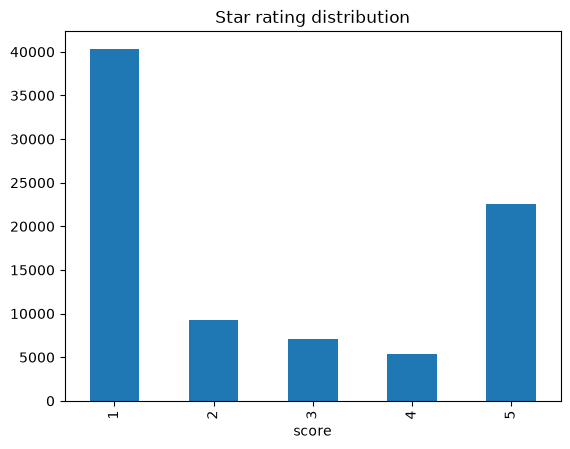

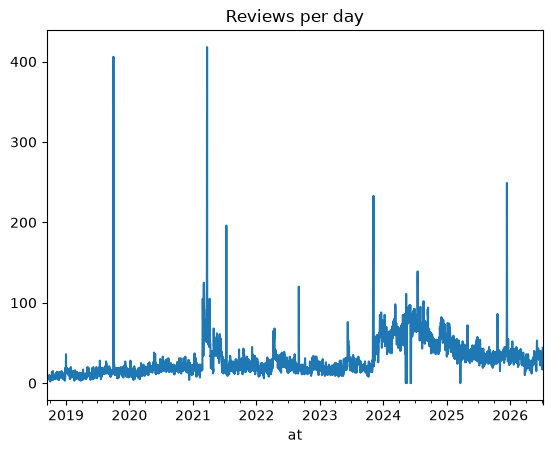

In [3]:
import matplotlib.pyplot as plt

df['score'].value_counts().sort_index().plot(kind='bar', title='Star rating distribution')
plt.show()

df.set_index('at').resample('D').size().plot(title='Reviews per day')
plt.show()

In [5]:
df.to_csv('../data/processed/cleaned_data.csv', index=False)

In [7]:
import os
print(os.path.exists('../data/processed/cleaned_data.csv'))

True
